In [2]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
from datetime import datetime

In [3]:
file_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_cytokine_stochastic_metrics"

In [6]:
directory = file_dir
today_midnight = 1771455600.0

files_today = []

for filename in os.listdir(directory):
    path = os.path.join(directory, filename)

    if not os.path.isfile(path):
        continue

    if os.path.getmtime(path) >= today_midnight:
        files_today.append(filename)

len(files_today)

37

In [7]:
output_dir = "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc/cellflow_stochastic_1_seen"
os.makedirs(output_dir, exist_ok=True)


In [8]:
dfs = []
for f in files_today:
    df = pd.read_csv(os.path.join(file_dir, f), index_col=0)
    df["reg"] = f.split("_")[-1].strip(".csv")
    dfs.append(df) 

df = pd.concat(dfs, axis=0)

In [9]:
df = df[df["reg"]=="0.1"]

In [10]:
len(df)

396

In [11]:
df["condition"] = df.index
df["donor"] = df.apply(lambda x: x["condition"].split("_")[0], axis=1)
df["cytokine"] = df.apply(lambda x: x["condition"].split("_")[1], axis=1)

In [12]:
df["one_minus_mean_deg_r_sq_per_cell_type"] = (1 - df["mean_deg_r_sq_per_cell_type"])

In [13]:
df_res_ls = []
for donor in df["donor"].unique():
    donor_dict = {}
    df_d = df[df["donor"]==donor]
    donor_dict["spearman_frechet"] = df_d[["frechet_variance", "mean_ood_e_distance"]].corr(method="spearman").iloc[0,1]
    donor_dict["pearson_frechet"] = df_d[["frechet_variance", "mean_ood_e_distance"]].corr(method="pearson").iloc[0,1]
    donor_dict["spearman_deg"] = df_d[["one_minus_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="spearman").iloc[0,1]
    donor_dict["pearson_deg"] = df_d[["one_minus_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="pearson").iloc[0,1]
    donor_dict["mean_r_sq_per_cell_type"] = df_d["mean_deg_r_sq_per_cell_type"].mean()
    donor_dict["mean_ood_e_distance"] = df_d["ood_e_distance_0"].mean()
    df_res_ls.append(pd.DataFrame.from_dict(donor_dict, orient="index", columns=[donor]).T)
    
df_res = pd.concat(df_res_ls)


In [14]:
x = df['one_minus_mean_deg_r_sq_per_cell_type']
y = df['mean_var_mean_deg_gex_per_cell_type']

def spearman_stat(data_x, data_y):
    return stats.spearmanr(data_x, data_y).correlation

res = stats.bootstrap((x, y), spearman_stat, vectorized=False, 
                      paired=True, n_resamples=9999)

print(f"Spearman Rho: {stats.spearmanr(x, y).correlation:.3f}")
print(f"95% CI: ({res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f})")

Spearman Rho: 0.564
95% CI: (0.488, 0.632)


In [15]:
x = df['one_minus_mean_deg_r_sq_per_cell_type']
y = df['mean_var_mean_deg_gex_per_cell_type']

def pearson_stat(data_x, data_y):
    return stats.pearsonr(data_x, data_y).correlation

res = stats.bootstrap((x, y), pearson_stat, vectorized=False, 
                      paired=True, n_resamples=9999)

print(f"Pearson Rho: {stats.pearsonr(x, y).correlation:.3f}")
print(f"95% CI: ({res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f})")

Pearson Rho: 0.651
95% CI: (0.558, 0.730)


In [16]:
x = df['frechet_variance']
y = df['mean_ood_e_distance']

def spearman_stat(data_x, data_y):
    return stats.spearmanr(data_x, data_y).correlation

res = stats.bootstrap((x, y), spearman_stat, vectorized=False, 
                      paired=True, n_resamples=9999)

print(f"Spearman Rho: {stats.spearmanr(x, y).correlation:.3f}")
print(f"95% CI: ({res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f})")

Spearman Rho: 0.602
95% CI: (0.531, 0.666)


In [17]:
x = df['frechet_variance']
y = df['mean_ood_e_distance']

def pearson_stat(data_x, data_y):
    return stats.pearsonr(data_x, data_y).correlation

res = stats.bootstrap((x, y), pearson_stat, vectorized=False, 
                      paired=True, n_resamples=9999)

print(f"Pearson Rho: {stats.pearsonr(x, y).correlation:.3f}")
print(f"95% CI: ({res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f})")

Pearson Rho: 0.493
95% CI: (0.379, 0.584)


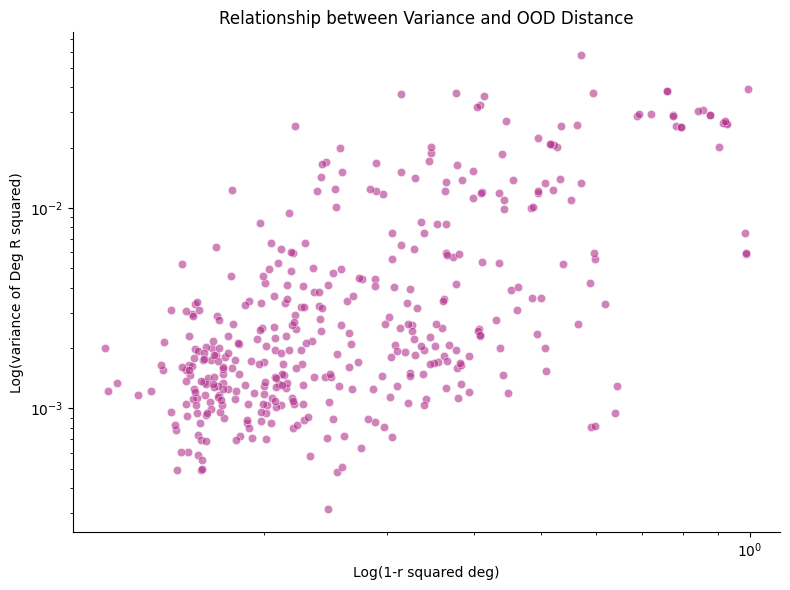

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(8, 6))

# Create the scatterplot
sns.scatterplot(
    data=df, 
    x='one_minus_mean_deg_r_sq_per_cell_type', 
    y='mean_var_mean_deg_gex_per_cell_type',
    color="#B12F8C",
    alpha=0.6,
    edgecolor="w"
)

# Apply log scales to both axes
plt.xscale('log')
plt.yscale('log')

# Clean up labels and title
plt.xlabel('Log(1-r squared deg)')
plt.ylabel('Log(variance of Deg R squared)')
plt.title('Relationship between Variance and OOD Distance')

# Remove unnecessary chart borders
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "calibration_deg.pdf"), format='pdf', dpi=300, bbox_inches='tight')
plt.show()

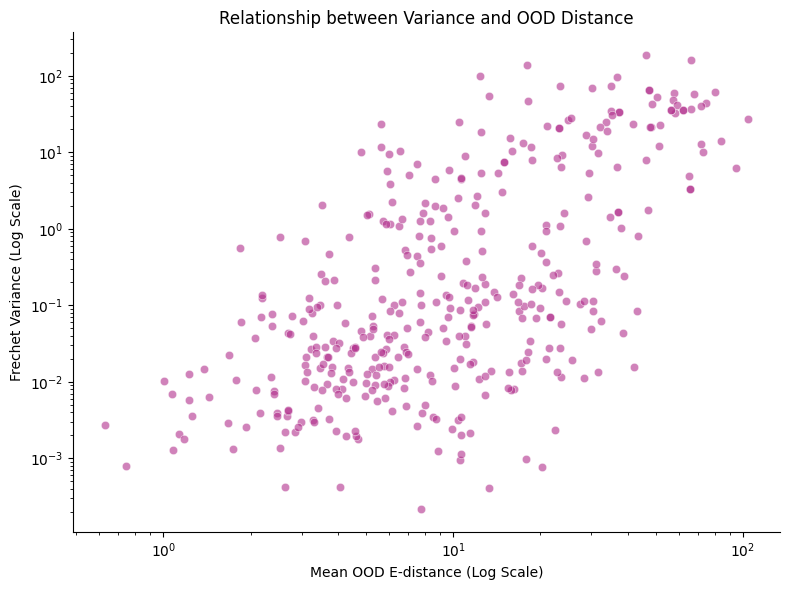

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(8, 6))

# Create the scatterplot
sns.scatterplot(
    data=df, 
    x='mean_ood_e_distance',
    y='frechet_variance', 
    color="#B12F8C",
    alpha=0.6,
    edgecolor="w"
)

# Apply log scales to both axes
plt.xscale('log')
plt.yscale('log')

# Clean up labels and title
plt.xlabel('Mean OOD E-distance (Log Scale)')
plt.ylabel('Frechet Variance (Log Scale)')
plt.title('Relationship between Variance and OOD Distance')

# Remove unnecessary chart borders
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "calibration_frechet.pdf"), format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
df_res

,spearman_frechet,pearson_frechet,spearman_deg,pearson_deg,mean_r_sq_per_cell_type,mean_ood_e_distance
Donor10,0.226050,0.294358,0.374790,0.320423,0.740648,16.548102
Donor11,0.563331,0.765815,0.431016,0.746424,0.664219,17.834147
Donor12,0.782735,0.739117,0.587166,0.794122,0.678286,11.433998
Donor1,0.476547,0.342467,0.549580,0.571948,0.657497,17.526287
Donor2,0.730787,0.705916,0.532468,0.663626,0.664919,14.178882
Donor4,0.635447,0.668252,0.650420,0.456878,0.747578,18.025403
Donor5,0.492743,0.344654,0.498854,0.666325,0.665264,11.381270
Donor6,0.725936,0.567396,0.735963,0.748672,0.703318,16.407927
Donor7,0.581665,0.792637,0.597861,0.723243,0.684995,9.064288
Donor8,0.418227,0.471968,0.482759,0.445363,0.662799,19.095411


In [21]:
df_res["donor"] = df_res.index

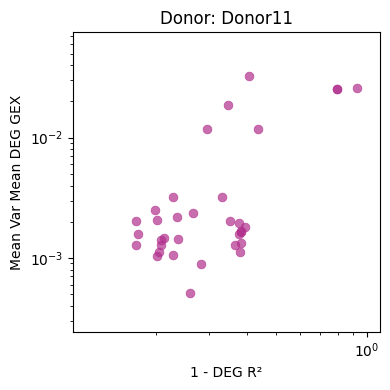

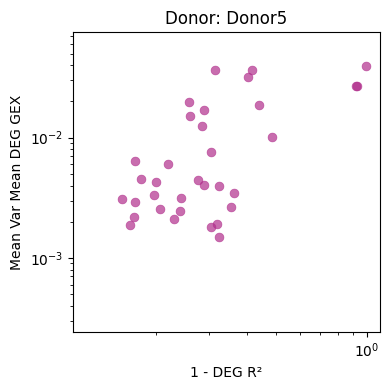

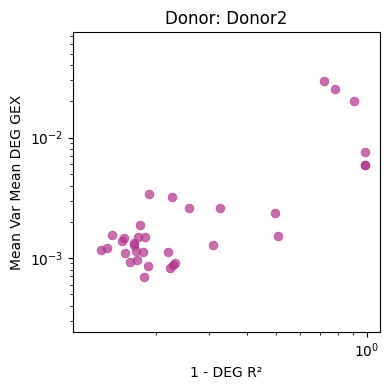

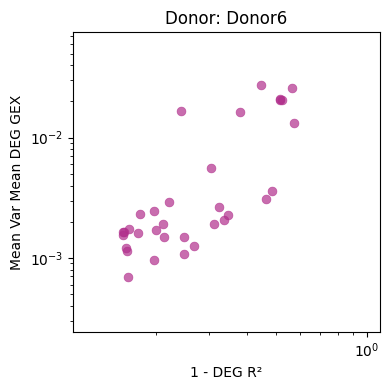

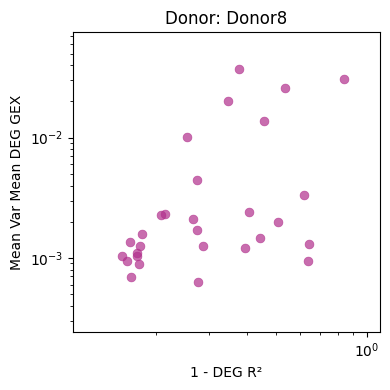

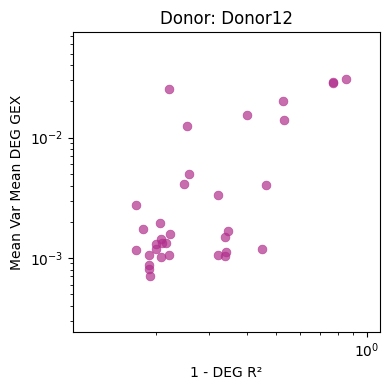

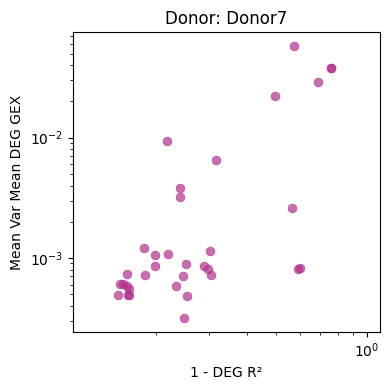

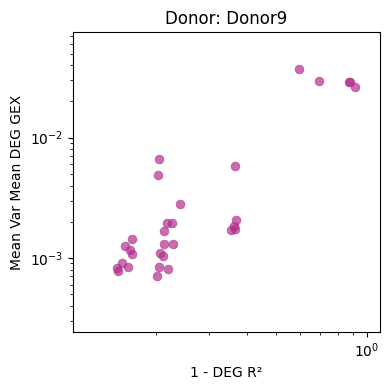

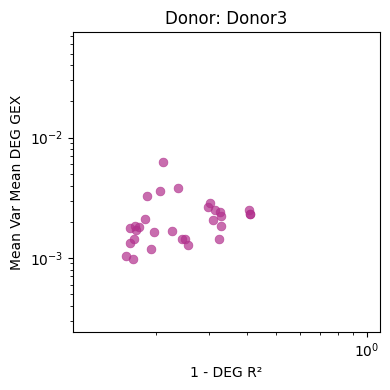

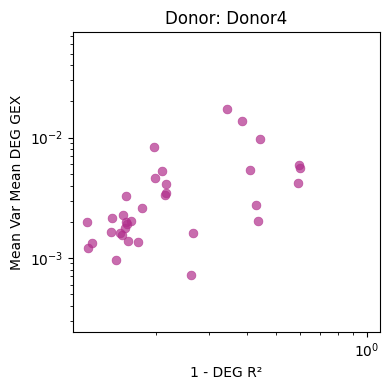

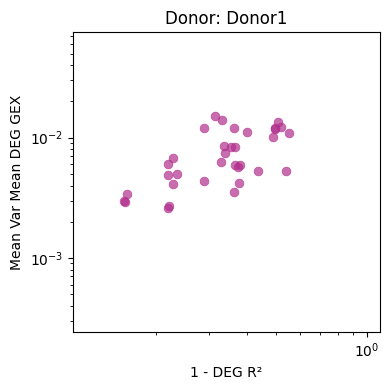

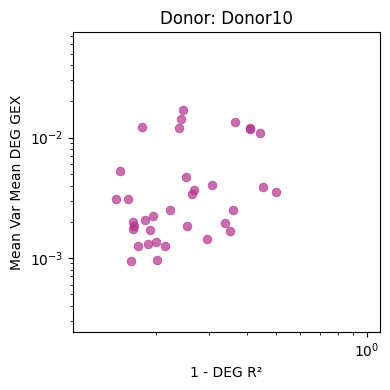

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

output_dir = "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc/cellflow_stochastic_1_seen"
os.makedirs(output_dir, exist_ok=True)

# 1. Define specific donor order
donor_order = [
    'Donor11', 'Donor5', 'Donor2', 'Donor6', 'Donor8', 'Donor12',
    'Donor7', 'Donor9', 'Donor3', 'Donor4', 'Donor1', 'Donor10'
]

x_col = "one_minus_mean_deg_r_sq_per_cell_type"
y_col = "mean_var_mean_deg_gex_per_cell_type"

# 2. Compute global limits with a 5% buffer
def get_log_buffered_limits(data_series, buffer=0.05):
    data = data_series[data_series > 0]  # log requires positive values
    log_data = np.log10(data)
    
    lmin, lmax = log_data.min(), log_data.max()
    lrange = lmax - lmin
    
    return 10**(lmin - lrange * buffer), 10**(lmax + lrange * buffer)

xmin, xmax = get_log_buffered_limits(df[x_col])
ymin, ymax = get_log_buffered_limits(df[y_col])

# 3. Iterate and Plot
for donor in donor_order:
    if donor not in df["donor"].values:
        continue
        
    df_tmp = df[df["donor"] == donor].copy()
    
    plt.figure(figsize=(4, 4))

    sns.scatterplot(
        data=df_tmp,
        x=x_col,
        y=y_col,
        alpha=0.7,
        edgecolor=None,
        s=40,
        color="#B12F8C"
    )

    plt.title(f"Donor: {donor}", fontsize=12)
    plt.xlabel("1 - DEG R²")
    plt.ylabel("Mean Var Mean DEG GEX")
    
    # Apply the buffered limits
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.xscale('log')
    plt.yscale('log')

    plt.tight_layout()

    # 4. Save and Show
    save_path = os.path.join(output_dir, f"{donor}_scatter_plot.pdf")
    plt.savefig(save_path, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close()

In [23]:
df_res = []
for cyto in df["cytokine"].unique():
    donor_dict = {}
    df_d = df[df["cytokine"]==cyto]
    donor_dict["spearman_frechet"] = df_d[["frechet_variance", "mean_ood_e_distance"]].corr(method="spearman").iloc[0,1]
    donor_dict["pearson_frechet"] = df_d[["frechet_variance", "mean_ood_e_distance"]].corr(method="pearson").iloc[0,1]
    donor_dict["spearman_deg"] = df_d[["one_minus_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="spearman").iloc[0,1]
    donor_dict["pearson_deg"] = df_d[["one_minus_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="pearson").iloc[0,1]
    donor_dict["mean_deg_r_sq_per_cell_type"] = df_d["mean_deg_r_sq_per_cell_type"].mean()
    donor_dict["mean_ood_e_distance"] = df_d["ood_e_distance_0"].mean()
    df_res.append(pd.DataFrame.from_dict(donor_dict, orient="index", columns=[cyto]).T)

df_res2 = pd.concat(df_res)


In [24]:
df_res2

,spearman_frechet,pearson_frechet,spearman_deg,pearson_deg,mean_deg_r_sq_per_cell_type,mean_ood_e_distance
OX40L,0.519719,0.521213,0.166110,0.045155,0.767544,13.735400
4-1BBL,0.479612,0.165632,0.562166,0.498009,0.822404,4.557036
IFN-beta,0.380682,0.130376,0.601270,0.444363,0.559019,32.366604
IL-13,0.238971,-0.043078,0.292447,0.201488,0.583916,22.743221
APRIL,0.281751,0.090287,0.174465,0.152861,0.794936,7.703177
ADSF,0.453543,0.742070,0.120655,0.801647,0.790898,9.835629
IL-15,0.505348,0.507894,0.485294,0.530048,0.299436,27.974497
BAFF,0.439840,0.066513,0.038102,0.272469,0.754233,6.519767
C5a,0.130348,0.563036,-0.258356,-0.020763,0.629301,19.703955
OSM,0.276738,0.389248,0.405414,0.594223,0.822621,5.619846


In [25]:
df_res2["cytokine"] = df_res2.index

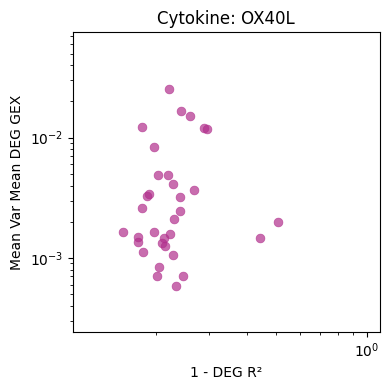

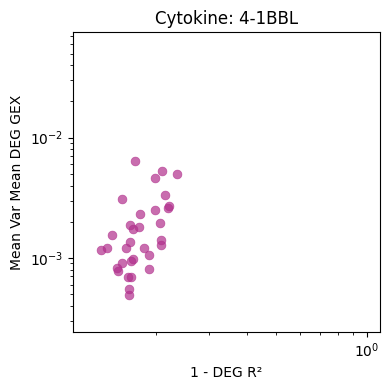

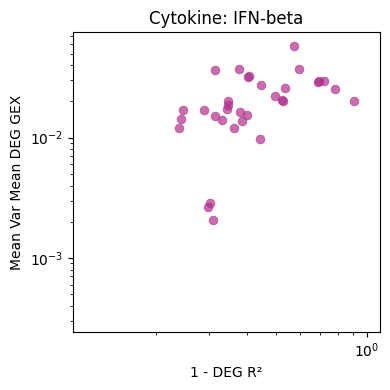

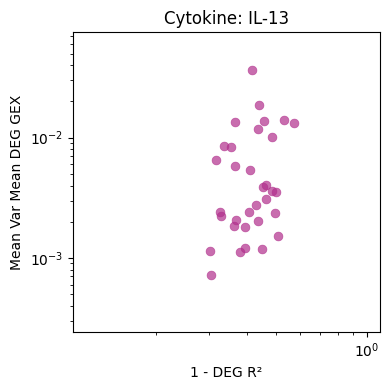

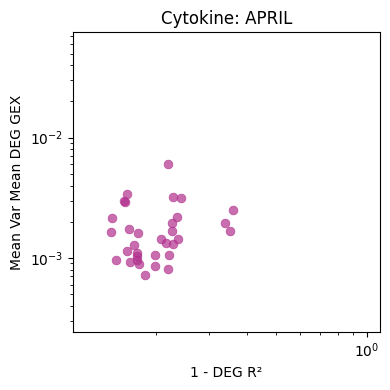

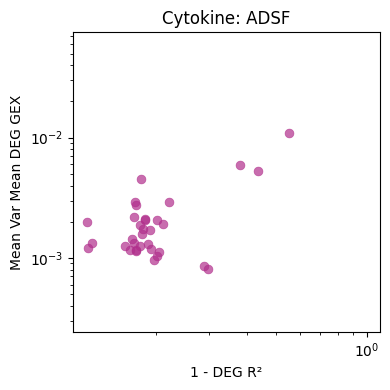

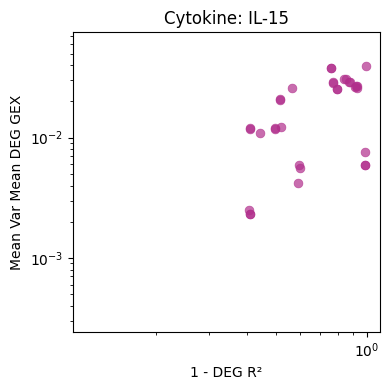

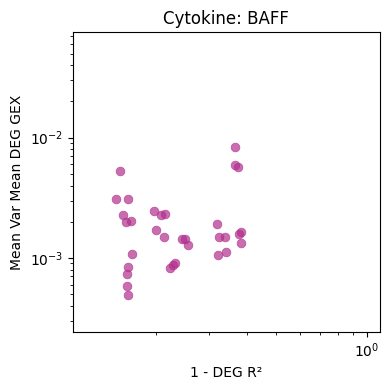

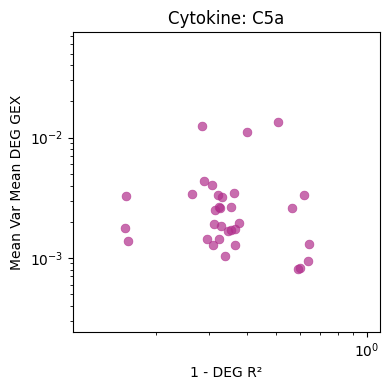

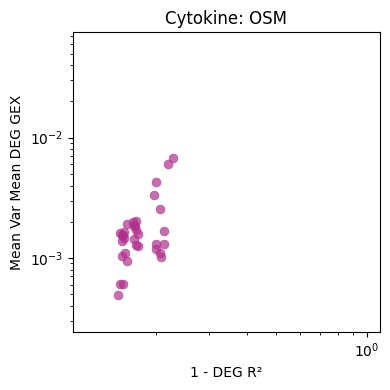

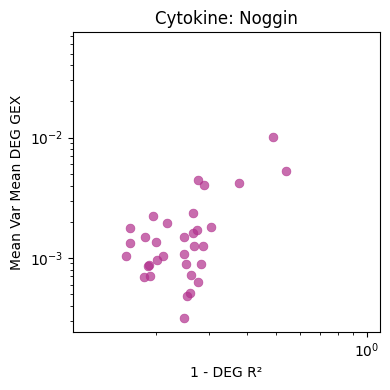

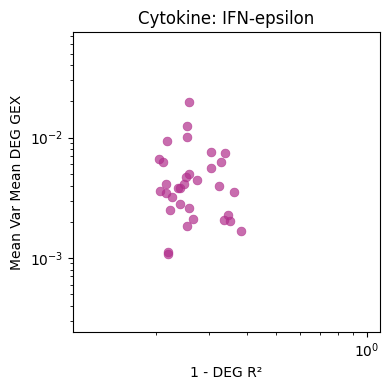

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os


# 1. Define specific donor order
cytokines = df["cytokine"].unique()

x_col = "one_minus_mean_deg_r_sq_per_cell_type"
y_col = "mean_var_mean_deg_gex_per_cell_type"

# 2. Compute global limits with a 5% buffer
def get_log_buffered_limits(data_series, buffer=0.05):
    data = data_series[data_series > 0]  # log requires positive values
    log_data = np.log10(data)
    
    lmin, lmax = log_data.min(), log_data.max()
    lrange = lmax - lmin
    
    return 10**(lmin - lrange * buffer), 10**(lmax + lrange * buffer)

xmin, xmax = get_log_buffered_limits(df[x_col])
ymin, ymax = get_log_buffered_limits(df[y_col])

# 3. Iterate and Plot
for cyto in cytokines:

    df_tmp = df[df["cytokine"] == cyto].copy()
    
    plt.figure(figsize=(4, 4))

    sns.scatterplot(
        data=df_tmp,
        x=x_col,
        y=y_col,
        alpha=0.7,
        edgecolor=None,
        s=40,
        color="#B12F8C"
    )

    plt.title(f"Cytokine: {cyto}", fontsize=12)
    plt.xlabel("1 - DEG R²")
    plt.ylabel("Mean Var Mean DEG GEX")

    plt.xscale('log')
    plt.yscale('log')

    
    # Apply the buffered limits
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.tight_layout()
    
    # 4. Save and Show
    save_path = os.path.join(output_dir, f"{cyto}_scatter_plot.pdf")
    plt.savefig(save_path, format="pdf", bbox_inches='tight')
    
    plt.show()
    plt.close()